# Аналіз характеристик

In [1]:
import json

import pandas as pd
from matplotlib import pyplot as plt

Читаємо `Zabrodin_file_2.json` та зберігаємо список необхідної інформації (ID, лема, частина мови, ID головного слова та тип зв'язку із головним словом).

In [2]:
INPUT_FILE = "../lab01/Zabrodin_file_2.json"

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

sentences = []
current = []

for line in data["result"].split("\n"):
    if line.startswith("#") or not line:
        if not line and current:
            sentences.append(current)
            current = []
        continue

    fields = line.split("\t")
    if len(fields) < 10:
        continue

    if "-" in fields[0]:  # skip multi-words
        continue

    current.append({
        "id": int(fields[0]),
        "lemma": fields[2],
        "upos": fields[3],
        "head": int(fields[6]),
        "deprel": fields[7],
    })

print(f"Речень: {len(sentences)}")
print(f"Токенів: {sum(len(s) for s in sentences)}")

Речень: 4344
Токенів: 56387


Читаємо словник тональностей української мови [https://github.com/Oksana504/sentimentdictionary-uk](https://github.com/Oksana504/sentimentdictionary-uk). Зберігаємо у `dataframe`, конвертуємо середнє значення тональності у `float64`.

In [3]:
INPUT_FILE = "tonSUM.2.0.csv"

df = pd.read_csv(INPUT_FILE, header=None)
df[9] = df[9].str.replace(",", ".").pipe(pd.to_numeric, errors="coerce").fillna(0)
sentiment = dict(zip(df[0], df[9]))

display(df)
df[9].dtype

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,абат,1,1,1,0,NaN,NaN,NaN,0.0,0.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,абатство,1,1,1,0,NaN,NaN,NaN,0.0,0.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,абетка,0,1,1,0,NaN,NaN,NaN,1.0,0.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,абзац,0,1,0,0,0.0,0.0,0.0,1.0,0.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,абітурієнт,2,2,0,2,NaN,NaN,NaN,1.0,1.40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14852,Microsoft,0,0,2,1,NaN,NaN,NaN,1.0,0.80,...,NaN,"""+",NaN,NaN,NaN,NaN,NaN,"майкрософт, Майкрософт",NaN,NaN
14853,OBSE,1,1,1,1,1.0,1.0,1.0,1.0,1.00,...,NaN,"""+",NaN,NaN,NaN,NaN,NaN,ОБСЄ,NaN,власна вставка
14854,UNICEF,1,0,0,2,NaN,NaN,NaN,1.0,0.80,...,NaN,"""+",NaN,NaN,NaN,NaN,NaN,ЮНІСЕФ,NaN,NaN
14855,WWF,1,2,2,2,2.0,2.0,2.0,2.0,1.88,...,World Wide Fund,"""+",NaN,NaN,NaN,NaN,NaN,NaN,NaN,власна вставка


dtype('float64')

З минулого завдання отримуємо список відфільтрованих персонажів.

In [4]:
INPUT_FILE = "../lab02/Zabrodin_characters_filtered.csv"

df_characters = pd.read_csv(INPUT_FILE)
characters = df_characters["Персонаж"].tolist()

characters

['Мотря',
 'Лаврін',
 'Кайдашиха',
 'Карпо',
 'Кайдаш',
 'Мелашка',
 'Палажка',
 'Параска',
 'Балаш',
 'Балашиха',
 'Берко',
 'Довбиш']

Для визначення потрібних залежностей [https://universaldependencies.org/u/dep/](https://universaldependencies.org/u/dep/).

In [5]:
OUTPUT_FILE = "Zabrodin_characters_tones_with_words.csv"

rows = []
for sentence in sentences:
    for word in sentence:
        for character in characters:
            if word["lemma"].lower() != character.lower():
                continue

            for w in sentence:
                # Лаврін СМІШНИЙ
                is_amod = w["head"] == word["id"] and w["deprel"] == "amod"

                # Лаврін СМІЯВСЯ
                is_nsubj = w["id"] == word["head"] and word["deprel"] == "nsubj" and w["upos"] == "VERB"

                # Лаврін ВЕСЕЛО сміявся
                is_advmod = w["upos"] == "ADV" and w["head"] == word["head"] and word["deprel"] == "nsubj" and w["deprel"] == "advmod"

                # Лаврін, ПАРУБОК, ...
                is_appos = w["head"] == word["id"] and w["deprel"] == "appos"

                # Лаврін виглядав СМІШНИМ
                is_xcomp = "xcomp" in w["deprel"] and any(
                    v["id"] == word["head"] and v["id"] == w["head"]
                    for v in sentence
                )

                if is_amod or is_nsubj or is_advmod or is_appos or is_xcomp:
                    rows.append({
                        "Персонаж": character,
                        "Лема": w["lemma"],
                        "Тональність": sentiment.get(w["lemma"], 0),
                    })

df_chars = pd.DataFrame(rows).drop_duplicates(subset=["Персонаж", "Лема"]).sort_values("Персонаж").reset_index(drop=True)
df_chars.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")
display(df_chars)

,Персонаж,Лема,Тональність
0,Балаш,тут,0.00
1,Балаш,сподіватися,0.75
2,Балаш,частувати,0.80
3,Балаш,старостіти,0.00
4,Балаш,жити,1.50
...,...,...,...
1110,Параска,кричати,-1.50
1111,Параска,оддалеки,0.00
1112,Параска,одскочити,0.00
1113,Параска,намовляти,0.00


Рахуємо загальну тональність персонажів

In [6]:
OUTPUT_FILE = "Zabrodin_characters_tone_general.csv"

df_tone = df_chars.groupby("Персонаж")["Тональність"].sum().reset_index()
df_tone.columns = ["Персонаж", "Тональність"]
df_tone = df_tone.sort_values("Тональність", ascending=False).reset_index(drop=True)

df_tone.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")
display(df_tone)

,Персонаж,Тональність
0,Мотря,34.27
1,Карпо,33.61
2,Лаврін,30.10
3,Мелашка,25.77
4,Кайдаш,25.01
5,Кайдашиха,21.97
6,Палажка,6.29
7,Довбиш,3.26
8,Балаш,3.23
9,Берко,2.72


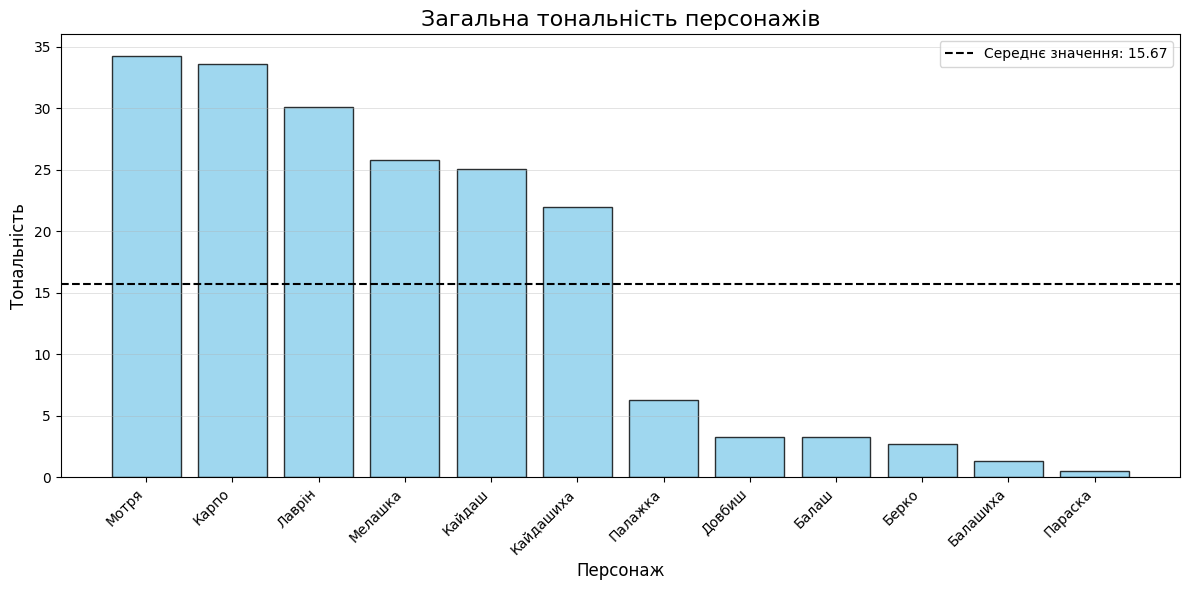

In [7]:
OUTPUT_IMAGE = "Zabrodin_tones_bar.png"

plt.figure(figsize=(12, 6))
plt.bar(df_tone["Персонаж"], df_tone["Тональність"], color="skyblue", edgecolor="black", alpha=0.8)

mean_tone = df_tone["Тональність"].mean()
plt.axhline(mean_tone, color="black", linestyle="--", label=f"Середнє значення: {mean_tone:.2f}")

plt.title("Загальна тональність персонажів", fontsize=16)
plt.xlabel("Персонаж", fontsize=12)
plt.ylabel("Тональність", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.grid(axis="y", linestyle="-", alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()

plt.savefig(OUTPUT_IMAGE, format="png", transparent=True, dpi=300)
plt.show()